# 🎭 The Four Horsemen of Coupling: A Comedy of Dependencies

> *"Any fool can write code that a computer can understand. Good programmers write code that humans can understand."*
> — **Martin Fowler** (who clearly never reviewed my first production codebase)

---

## Table of Contents

1. [The Setup](#the-setup)
2. [Afferent Coupling (Ca) — Your Popularity Contest](#1-afferent-coupling-ca--your-popularity-contest)
3. [Efferent Coupling (Ce) — Your Trust Issues](#2-efferent-coupling-ce--your-trust-issues)
4. [Chart: Ca vs Ce in the Wild](#chart-ca-vs-ce-in-the-wild)
5. [Instability (I) — The Plot Twist](#3-instability-i--the-plot-twist)
6. [Chart: The Instability Surface](#chart-the-instability-surface)
7. [Abstractness (A) — The Philosophical One](#4-abstractness-a--the-philosophical-one)
8. [The Grand Finale — The Main Sequence](#the-grand-finale--the-main-sequence)
9. [Chart: The Main Sequence Plot](#chart-the-main-sequence-plot)
10. [Putting It All Together](#putting-it-all-together)
11. [References](#references)


---

## The Setup

Picture this: it's 2 AM. You just renamed a single field in your `OrderService`. Twelve minutes later, `InventoryService` is throwing exceptions, `NotificationService` has gone silent, and Finance is sending you Slack messages about *"infinite spinners."* ♾️💀

**One field. Three services down.** Your "microservices architecture" is really just a monolith in a trench coat pretending to be several smaller services at a party.<sup>[1]</sup>

Here's the good news: Robert C. Martin handed us a crystal ball back in the 1990s — four simple metrics that can predict these catastrophes *before* they detonate your on-call rotation. No machine learning required. Just arithmetic and, occasionally, an absolute value.

Let's meet the cast.


In [1]:
# ── Setup ────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib import patheffects
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Consistent palette (from Steven's visualization reference)
COLORS = {
    'stable':    '#2A9D8F',   # teal
    'balanced':  '#E9C46A',   # bronze/gold
    'borderline':'#F4A261',   # copper/orange
    'volatile':  '#E76F51',   # burnt red
    'abstract':  '#7B2D8E',   # purple
    'pain':      '#C1121F',   # red
    'useless':   '#999999',   # gray
    'main_seq':  '#264653',   # dark navy
    'bg':        '#FCF5E5',   # warm parchment
    'text':      '#504D47',   # dark brown
}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor':   '#FFFDF7',
    'axes.edgecolor':   COLORS['text'],
    'text.color':       COLORS['text'],
    'font.family':      'serif',
    'font.size':        12,
    'axes.titlesize':   16,
    'axes.labelsize':   13,
})

print("✅ Libraries loaded. Let's talk about coupling!")


✅ Libraries loaded. Let's talk about coupling!


---

## 1. Afferent Coupling (Ca) — Your Popularity Contest

**Afferent Coupling** counts how many external modules depend on *your* module. Think of it as your module's follower count — except instead of Instagram likes, these followers will *riot* if you change anything.

$$\text{Ca} = \text{count of modules that import yours}$$

The analogy that sticks? **Ca counts your creditors.** These modules have invested in your stability. They rely on your public API the way your landlord relies on your rent check: with very specific expectations and zero tolerance for surprises.

| Ca Value | Interpretation | Emotional State |
|:--------:|----------------|-----------------|
| **0** | Nobody depends on you | Liberating... and a little sad |
| **1–5** | Normal dependency | Comfortable responsibility |
| **5–15** | Popular module | Refactor with care |
| **15+** | Load-bearing wall | Don't. Touch. Anything. |

> 📊 **High Ca = high responsibility.** If Ca = 15, that means fifteen other modules will potentially break when you refactor. You're the load-bearing wall of the codebase. Renovate with extreme caution — or don't sleep near your phone.


---

## 2. Efferent Coupling (Ce) — Your Trust Issues

**Efferent Coupling** counts how many external modules *your* module depends on. This is the inverse: not who trusts you, but who you've decided to trust.

$$\text{Ce} = \text{count of modules your module imports}$$

Here the analogy flips: **Ce counts your debts.** Every dependency is a bet that *someone else's* code won't break, won't introduce a vulnerability, and won't decide to publish a breaking change on a Friday afternoon.<sup>[2]</sup>

| Ce Value | Interpretation | Emotional State |
|:--------:|----------------|-----------------|
| **0** | Depends on nothing | Blissful isolation |
| **1–5** | Normal imports | Business as usual |
| **5–15** | Many dependencies | Starting to sweat |
| **15+** | Dependency hoarder | You ARE the blast radius |

> 📊 **High Ce = high vulnerability.** Your module is only as reliable as its least reliable dependency — and let's be honest, we've all `npm install`-ed something sketchy at 4 PM on a Friday.


---

### Chart: Ca vs Ce in the Wild

Let's plot some hypothetical modules to see how Ca and Ce shape their character. Each bubble represents a module — the position shows its coupling profile, and the color shows its computed instability.


/var/folders/rv/nyr677093739kwpzd7mny_hm0000gn/T/ipykernel_7816/2673197943.py:67: UserWarning: Glyph 127811 (\N{LEAF FLUTTERING IN WIND}) missing from font(s) DejaVu Serif.
  fig.tight_layout()
/Users/windfox/src/git-steven.github.io/python-git-steven/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127811 (\N{LEAF FLUTTERING IN WIND}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


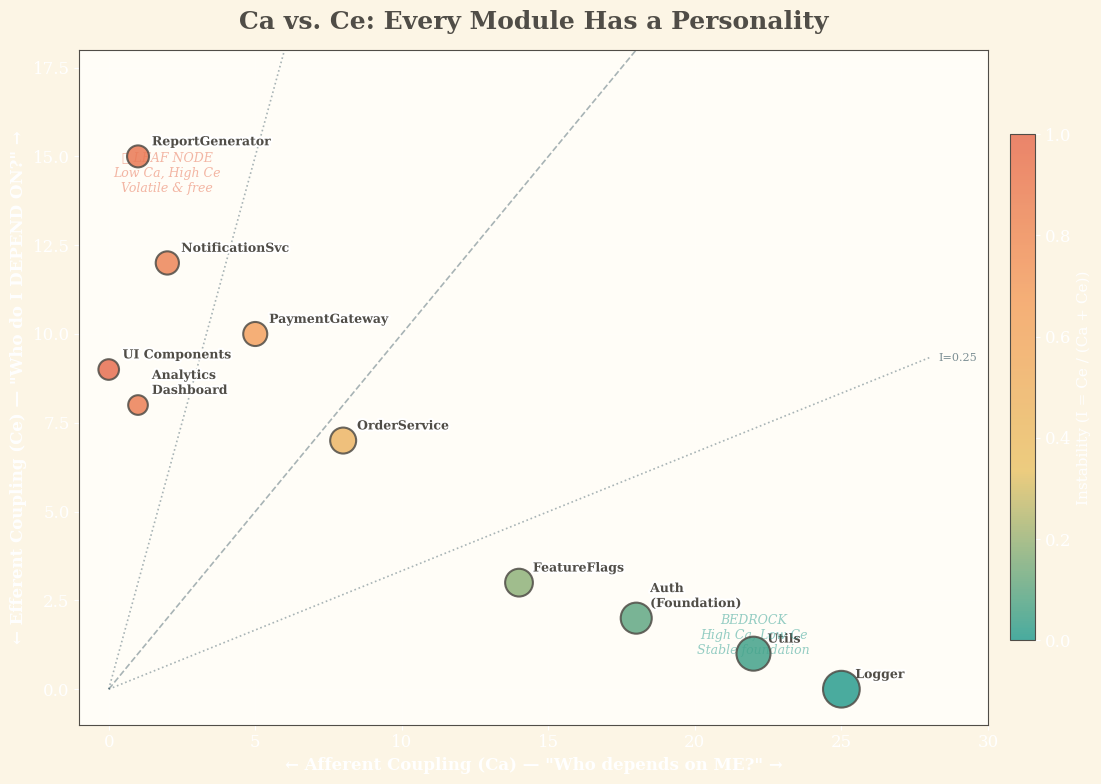

In [8]:
# ── Ca vs Ce Scatter with Instability coloring ─────────────
modules = {
    'Auth\n(Foundation)':    {'ca': 18, 'ce': 2,  'size': 500},
    'Utils':                 {'ca': 22, 'ce': 1,  'size': 600},
    'OrderService':          {'ca': 8,  'ce': 7,  'size': 350},
    'PaymentGateway':        {'ca': 5,  'ce': 10, 'size': 300},
    'NotificationSvc':       {'ca': 2,  'ce': 12, 'size': 280},
    'ReportGenerator':       {'ca': 1,  'ce': 15, 'size': 250},
    'FeatureFlags':          {'ca': 14, 'ce': 3,  'size': 400},
    'UI Components':         {'ca': 0,  'ce': 9,  'size': 220},
    'Logger':                {'ca': 25, 'ce': 0,  'size': 700},
    'Analytics\nDashboard':  {'ca': 1,  'ce': 8,  'size': 200},
}

fig, ax = plt.subplots(figsize=(12, 8))

cas = [m['ca'] for m in modules.values()]
ces = [m['ce'] for m in modules.values()]
sizes = [m['size'] for m in modules.values()]
instabilities = [ce / (ca + ce) if (ca + ce) > 0 else 0.5
                 for ca, ce in zip(cas, ces)]

# Custom colormap: teal (stable) → gold → orange → red (volatile)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'instability',
    [COLORS['stable'], COLORS['balanced'], COLORS['borderline'], COLORS['volatile']]
)

scatter = ax.scatter(cas, ces, c=instabilities, cmap=cmap,
                     s=sizes, alpha=0.85, edgecolors=COLORS['text'],
                     linewidths=1.5, vmin=0, vmax=1, zorder=5)

# Labels
for name, data in modules.items():
    ax.annotate(name, (data['ca'], data['ce']),
                textcoords="offset points", xytext=(10, 8),
                fontsize=9, fontweight='bold', color=COLORS['text'],
                path_effects=[patheffects.withStroke(linewidth=3, foreground='white')])

# Diagonal reference lines for constant I
for i_val, label, ls in [(0.25, 'I=0.25', ':'), (0.5, 'I=0.5', '--'), (0.75, 'I=0.75', ':')]:
    xs = np.linspace(0, 28, 100)
    # I = Ce/(Ca+Ce) → Ce = I*Ca / (1-I)
    ys = i_val * xs / (1 - i_val)
    ax.plot(xs, ys, ls=ls, color=COLORS['main_seq'], alpha=0.4, lw=1.2)
    # Label at right edge
    y_at_28 = i_val * 28 / (1 - i_val)
    if y_at_28 <= 20:
        ax.text(28.3, y_at_28, label, fontsize=8, color=COLORS['main_seq'], alpha=0.6, va='center')

cbar = fig.colorbar(scatter, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('Instability (I = Ce / (Ca + Ce))', fontsize=11)

ax.set_xlabel('← Afferent Coupling (Ca) — "Who depends on ME?" →', fontsize=12, fontweight='bold')
ax.set_ylabel('← Efferent Coupling (Ce) — "Who do I DEPEND ON?" →', fontsize=12, fontweight='bold')
ax.set_title('Ca vs. Ce: Every Module Has a Personality', fontsize=18, fontweight='bold', pad=15)

# Quadrant annotations
ax.text(22, 1, 'BEDROCK\nHigh Ca, Low Ce\nStable foundation',
        fontsize=9, ha='center', style='italic', alpha=0.5, color=COLORS['stable'])
ax.text(2, 14, '🍃 LEAF NODE\nLow Ca, High Ce\nVolatile & free',
        fontsize=9, ha='center', style='italic', alpha=0.5, color=COLORS['volatile'])

ax.set_xlim(-1, 30)
ax.set_ylim(-1, 18)
ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()


---

## 3. Instability (I) — The Plot Twist

Now we combine our two protagonists into a single, devastatingly informative ratio:

$$I = \frac{Ce}{Ca + Ce}$$

The **Instability Index** ranges from 0 to 1, and it answers one deceptively simple question: *"If something changes in the ecosystem, how likely is this module to need changing too?"*

| I Value | Zone | What It Means | Your Emotional State |
|:-------:|:----:|---------------|----------------------|
| **0.00 – 0.25** | 🟢 Stable | Many dependents, few dependencies. You're the foundation. | Quietly terrified of breaking everyone |
| **0.25 – 0.50** | 🟡 Mostly Stable | The Goldilocks zone. Normal development pace. | Cautiously optimistic |
| **0.50 – 0.75** | 🟠 Unstable | Caution zone. Dependencies are starting to outnumber dependents. | Nervously monitoring Slack |
| **0.75 – 1.00** | 🔴 Volatile | Few dependents, many dependencies. Change freely — nobody cares about you anyway. | Existential freedom (and loneliness) |

There's a beautiful paradox here: **the modules everyone depends on (high Ca) are the hardest to change, while the modules nobody depends on (low Ca) can change freely.** It's the architectural equivalent of being famous — you can't just reinvent yourself on a Tuesday.<sup>[3]</sup>

When **Ca = 0** (nobody depends on you), the formula yields **I = 1.0** — maximum instability. The module is a leaf node. It can thrash around all it wants because nobody's watching.

When **Ce = 0** (you depend on nothing), **I = 0.0** — maximum stability. You're a bedrock utility with no external attack surface.


---

### Chart: The Instability Surface

Let's visualize how Instability changes across all possible combinations of Ca and Ce. This 3D surface and its heatmap projection reveal the landscape architects navigate every day.


In [9]:
# ── Interactive 3D Surface: Instability as f(Ca, Ce) ─────────
ca_range = np.arange(0, 21, 1)
ce_range = np.arange(0, 21, 1)
Ca, Ce = np.meshgrid(ca_range, ce_range)

# Avoid division by zero
total = Ca + Ce
with np.errstate(divide='ignore', invalid='ignore'):
    I_surface = np.where(total > 0, Ce / total, 0.5)

# ── 3D Surface Plot (Plotly) ──────────────────────────────────
fig_3d = go.Figure(data=[go.Surface(
    x=ca_range, y=ce_range, z=I_surface,
    colorscale=[
        [0.00, '#2A9D8F'],   # stable teal
        [0.25, '#2A9D8F'],
        [0.25, '#E9C46A'],   # balanced gold
        [0.50, '#E9C46A'],
        [0.50, '#F4A261'],   # borderline copper
        [0.75, '#F4A261'],
        [0.75, '#E76F51'],   # volatile red
        [1.00, '#E76F51'],
    ],
    colorbar=dict(
        title='I',
        tickvals=[0, 0.25, 0.5, 0.75, 1.0],
        ticktext=['0.0 Stable', '0.25', '0.5', '0.75', '1.0 Volatile']
    ),
    contours=dict(
        z=dict(show=True, usecolormap=True, project_z=True, highlightcolor="limegreen", size=0.125)
    ),
    hovertemplate='Ca: %{x}<br>Ce: %{y}<br>I: %{z:.2f}<extra></extra>',
    opacity=0.92,
)])

fig_3d.update_layout(
    title=dict(text='🏔️ Instability Surface: I = Ce / (Ca + Ce)', font=dict(size=20)),
    scene=dict(
        xaxis_title='Afferent Coupling (Ca)',
        yaxis_title='Efferent Coupling (Ce)',
        zaxis_title='Instability (I)',
        xaxis=dict(range=[0, 20]),
        yaxis=dict(range=[0, 20]),
        zaxis=dict(range=[0, 1]),
        camera=dict(eye=dict(x=1.8, y=-1.5, z=1.0)),
        bgcolor='#FFFDF7',
    ),
    paper_bgcolor=COLORS['bg'],
    width=800,
    height=600,
    margin=dict(l=10, r=10, t=60, b=10),
)
fig_3d.show()


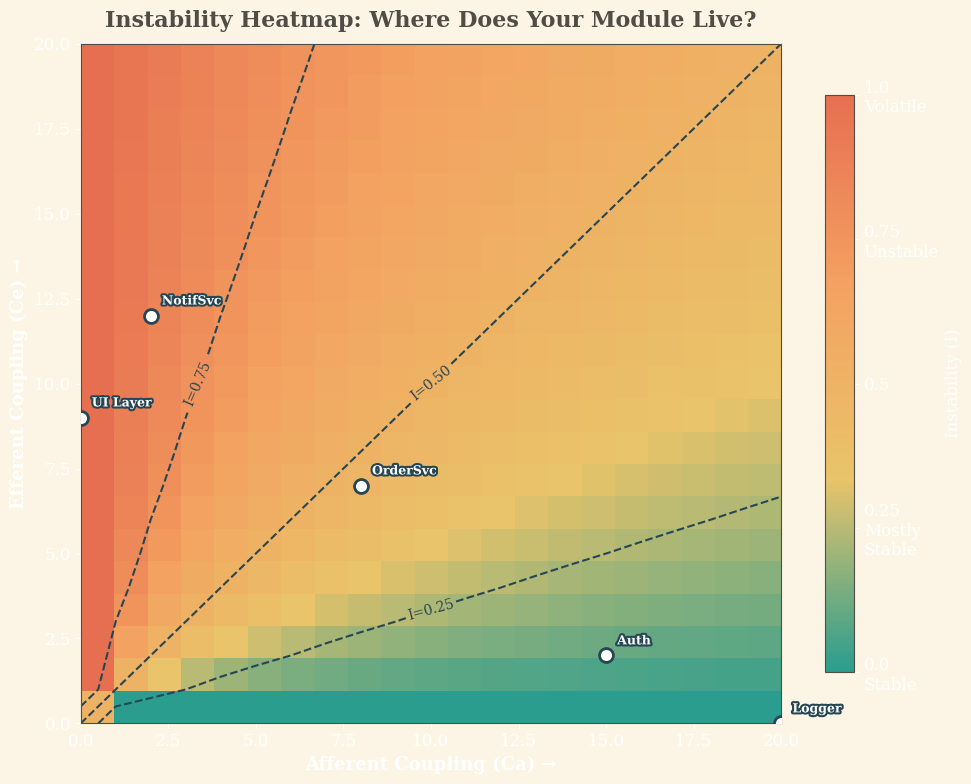

In [6]:
# ── Heatmap projection (matplotlib) ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

cmap_heat = mcolors.LinearSegmentedColormap.from_list(
    'instability_heat',
    [COLORS['stable'], COLORS['balanced'], COLORS['borderline'], COLORS['volatile']]
)

im = ax.imshow(I_surface, origin='lower', aspect='auto',
               extent=[0, 20, 0, 20], cmap=cmap_heat, vmin=0, vmax=1)

# Contour lines for key I values
contour = ax.contour(Ca, Ce, I_surface, levels=[0.25, 0.5, 0.75],
                     colors=[COLORS['main_seq']], linewidths=1.5, linestyles='--')
ax.clabel(contour, fmt='I=%.2f', fontsize=10, colors=COLORS['main_seq'])

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Instability (I)', fontsize=12)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.0\nStable', '0.25\nMostly\nStable', '0.5', '0.75\nUnstable', '1.0\nVolatile'])

# Mark some example modules
examples = [
    ('Logger', 20, 0), ('Auth', 15, 2), ('OrderSvc', 8, 7),
    ('NotifSvc', 2, 12), ('UI Layer', 0, 9),
]
for name, ca, ce in examples:
    ax.plot(ca, ce, 'o', color='white', markersize=10, markeredgecolor=COLORS['main_seq'], markeredgewidth=2, zorder=10)
    ax.annotate(name, (ca, ce), textcoords="offset points", xytext=(8, 8),
                fontsize=9, fontweight='bold', color='white',
                path_effects=[patheffects.withStroke(linewidth=3, foreground=COLORS['main_seq'])])

ax.set_xlabel('Afferent Coupling (Ca) →', fontsize=13, fontweight='bold')
ax.set_ylabel('Efferent Coupling (Ce) →', fontsize=13, fontweight='bold')
ax.set_title('Instability Heatmap: Where Does Your Module Live?', fontsize=16, fontweight='bold', pad=12)
fig.tight_layout()
plt.show()


---

## 4. Abstractness (A) — The Philosophical One

If Instability tells you *how fragile* a module is, **Abstractness** tells you *how committed* it is to specific implementations:

$$A = \frac{N_a}{N_c}$$

Where **Nₐ** is the number of abstract types (interfaces, abstract classes) and **N_c** is the total number of types in the module.

| A Value | Meaning | Real-World Analogy |
|:-------:|---------|-------------------|
| **0.0** | Purely concrete | A recipe that says *"exactly 237ml of Heinz ketchup"* |
| **0.5** | Balanced mix | A recipe that says *"tomato-based condiment, dealer's choice"* |
| **1.0** | Purely abstract | A recipe that says *"add flavor"* and walks away |

**A = 0** means your module is nothing but concrete implementations. Every class is a specific, nailed-down thing. This is fine for volatile leaf modules (high I), but *terrifying* for stable foundational ones (low I) — because changing a concrete implementation in a module that 47 other modules depend on is how you get paged at 2 AM.

**A = 1** means your module is *all* interfaces and no implementations. It's the architectural equivalent of a philosophy degree: intellectually beautiful, but someone still has to actually *do the work* somewhere.<sup>[4]</sup>


---

## The Grand Finale — The Main Sequence

Here's where Martin's genius truly shines. Plot **Abstractness (A)** on the Y-axis and **Instability (I)** on the X-axis, and draw a line from (0, 1) to (1, 0). That diagonal is the **Main Sequence** — the ideal balance between abstractness and instability:

$$A + I = 1$$

The relationship is elegantly simple:

- **Stable modules** (low I) should be **abstract** (high A), because they need to absorb change through extension rather than modification.
- **Unstable modules** (high I) should be **concrete** (low A), because nobody depends on them anyway — just rewrite them.

Modules that violate this balance land in two infamous danger zones:

| Zone | Location | Problem | Classic Residents |
|------|----------|---------|-------------------|
| **🔴 Zone of Pain** | Bottom-left (low A, low I) | Concrete AND stable → rigid, brittle | DB schemas, `Utils.java` that Dave wrote in 2017 |
| **⚪ Zone of Uselessness** | Top-right (high A, high I) | Abstract AND unstable → unused fluff | Over-engineered plugin systems nobody extends |

The **Distance from the Main Sequence** wraps a bow on everything:

$$D = |A + I - 1|$$

**D = 0** is perfection. **D = 1** means you're deep in a danger zone, and it's time for an architectural retrospective, a strong coffee, and possibly a therapist.<sup>[5]</sup>


---

### Chart: The Main Sequence Plot

This is the crown jewel. Each module is plotted by its Abstractness and Instability, revealing whether it sits in healthy territory or has drifted into pain or uselessness.


/var/folders/rv/nyr677093739kwpzd7mny_hm0000gn/T/ipykernel_78426/188191181.py:88: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Serif.
  fig.tight_layout()
/var/folders/rv/nyr677093739kwpzd7mny_hm0000gn/T/ipykernel_78426/188191181.py:88: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Serif.
  fig.tight_layout()
/var/folders/rv/nyr677093739kwpzd7mny_hm0000gn/T/ipykernel_78426/188191181.py:88: UserWarning: Glyph 9898 (\N{MEDIUM WHITE CIRCLE}) missing from font(s) DejaVu Serif.
  fig.tight_layout()
/Users/windfox/src/git-steven.github.io/python-git-steven/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/windfox/src/git-steven.github.io/python-git-steven/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from 

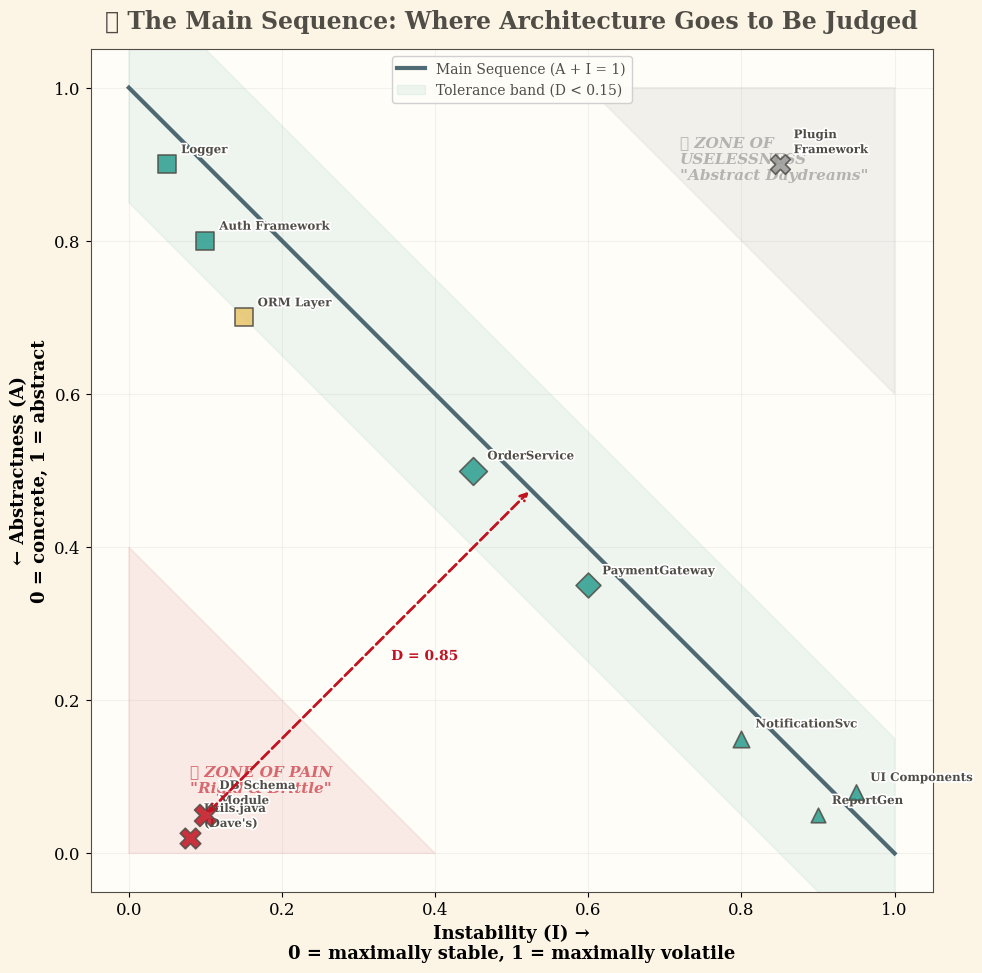

In [5]:
# ── The Main Sequence Plot (A vs I) ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

# Zone shading
# Zone of Pain (bottom-left triangle)
pain_x = [0, 0.4, 0, 0]
pain_y = [0, 0, 0.4, 0]
ax.fill(pain_x, pain_y, color=COLORS['pain'], alpha=0.08, zorder=1)
ax.text(0.08, 0.08, '🔴 ZONE OF PAIN\n"Rigid & Brittle"',
        fontsize=11, fontweight='bold', color=COLORS['pain'], alpha=0.6, style='italic')

# Zone of Uselessness (top-right triangle)
useless_x = [0.6, 1, 1, 0.6]
useless_y = [1, 0.6, 1, 1]
ax.fill(useless_x, useless_y, color=COLORS['useless'], alpha=0.12, zorder=1)
ax.text(0.72, 0.88, '⚪ ZONE OF\nUSELESSNESS\n"Abstract Daydreams"',
        fontsize=11, fontweight='bold', color=COLORS['useless'], alpha=0.7, style='italic')

# Main Sequence line
ax.plot([0, 1], [1, 0], color=COLORS['main_seq'], linewidth=3,
        linestyle='-', alpha=0.8, zorder=3, label='Main Sequence (A + I = 1)')

# Tolerance band
band_offset = 0.15
ax.fill_between([0, 1], [1 + band_offset, 0 + band_offset],
                [1 - band_offset, 0 - band_offset],
                color=COLORS['stable'], alpha=0.08, zorder=2, label=f'Tolerance band (D < {band_offset})')

# Example modules
module_data = [
    # (name,   I,    A,    marker, size, description)
    ('Logger',              0.05, 0.90, 's', 180, 'Near-perfect: stable & abstract'),
    ('Auth Framework',      0.10, 0.80, 's', 160, 'Solid foundation'),
    ('ORM Layer',           0.15, 0.70, 's', 150, 'Healthy core'),
    ('OrderService',        0.45, 0.50, 'D', 200, 'Balanced'),
    ('PaymentGateway',      0.60, 0.35, 'D', 160, 'Slightly concrete for its instability'),
    ('NotificationSvc',     0.80, 0.15, '^', 140, 'Volatile leaf — fine'),
    ('UI Components',       0.95, 0.08, '^', 120, 'Max volatile, max concrete — OK!'),
    ('ReportGen',           0.90, 0.05, '^', 110, 'Leaf node, concrete'),
    # Danger zone residents
    ('DB Schema\nModule',   0.10, 0.05, 'X', 250, '💀 PAIN: concrete + stable'),
    ('Utils.java\n(Dave\'s)',0.08, 0.02, 'X', 220, '💀 PAIN: God class'),
    ('Plugin\nFramework',   0.85, 0.90, 'X', 200, '👻 USELESS: abstract + nobody cares'),
]

for name, i_val, a_val, marker, size, desc in module_data:
    d = abs(a_val + i_val - 1)
    # Color by distance from main sequence
    if d < 0.15:
        color = COLORS['stable']
    elif d < 0.3:
        color = COLORS['balanced']
    elif marker == 'X' and a_val < 0.3:
        color = COLORS['pain']
    else:
        color = COLORS['useless']

    ax.scatter(i_val, a_val, c=color, s=size, marker=marker,
              edgecolors=COLORS['text'], linewidths=1.2, alpha=0.85, zorder=6)
    ax.annotate(name, (i_val, a_val), textcoords="offset points",
                xytext=(10, 8), fontsize=8.5, fontweight='bold', color=COLORS['text'],
                path_effects=[patheffects.withStroke(linewidth=2.5, foreground='white')])

# Distance annotation for one module
# Draw a line from DB Schema Module to the Main Sequence
db_i, db_a = 0.10, 0.05
# Closest point on A+I=1 line: project (i,a) onto the line
proj_i = (1 + db_i - db_a) / 2
proj_a = (1 - db_i + db_a) / 2
ax.annotate('', xy=(proj_i, proj_a), xytext=(db_i, db_a),
            arrowprops=dict(arrowstyle='<->', color=COLORS['pain'], lw=2, ls='--'))
d_val = abs(db_a + db_i - 1)
mid_i = (db_i + proj_i) / 2
mid_a = (db_a + proj_a) / 2
ax.text(mid_i + 0.03, mid_a - 0.01, f'D = {d_val:.2f}', fontsize=10,
        color=COLORS['pain'], fontweight='bold',
        path_effects=[patheffects.withStroke(linewidth=2.5, foreground='white')])

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Instability (I) →\n0 = maximally stable, 1 = maximally volatile', fontsize=13, fontweight='bold')
ax.set_ylabel('← Abstractness (A)\n0 = concrete, 1 = abstract', fontsize=13, fontweight='bold')
ax.set_title('📐 The Main Sequence: Where Architecture Goes to Be Judged',
             fontsize=17, fontweight='bold', pad=15)
ax.set_aspect('equal')
ax.legend(loc='upper center', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()


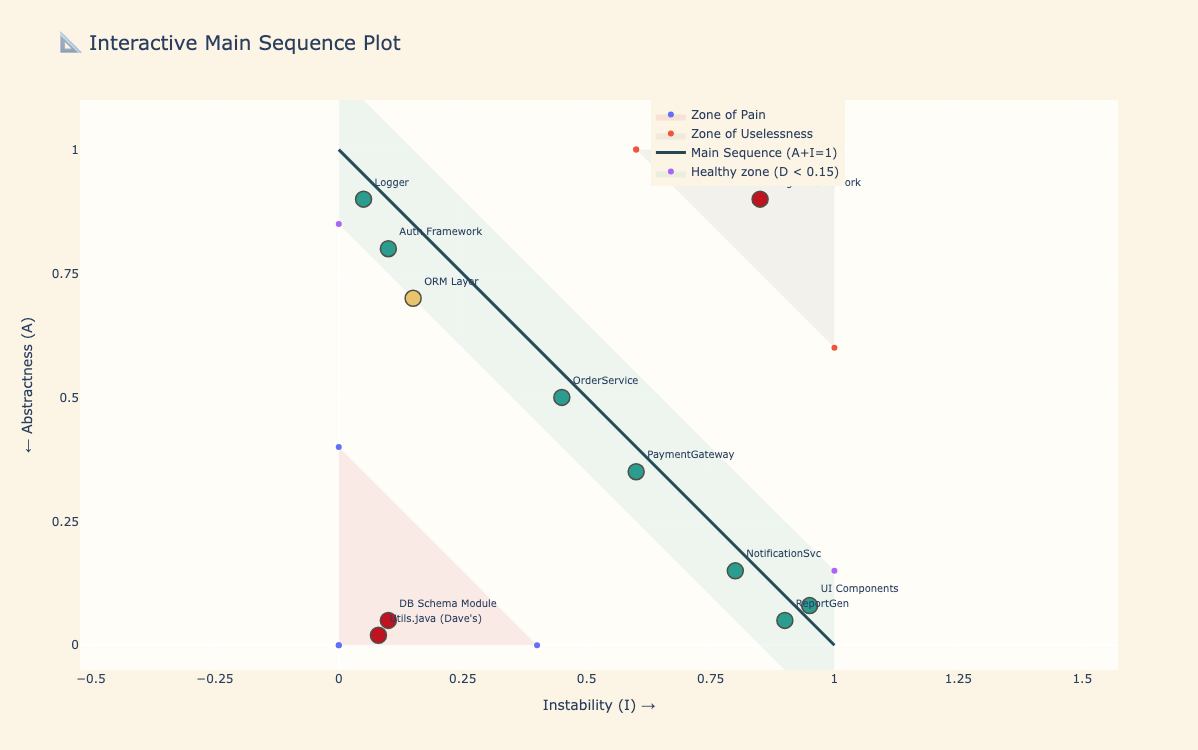

In [6]:
# ── Interactive Main Sequence (Plotly) ────────────────────────
module_names = ['Logger', 'Auth Framework', 'ORM Layer', 'OrderService',
                'PaymentGateway', 'NotificationSvc', 'UI Components',
                'ReportGen', 'DB Schema Module', "Utils.java (Dave's)", 'Plugin Framework']
i_vals =       [0.05, 0.10, 0.15, 0.45, 0.60, 0.80, 0.95, 0.90, 0.10, 0.08, 0.85]
a_vals =       [0.90, 0.80, 0.70, 0.50, 0.35, 0.15, 0.08, 0.05, 0.05, 0.02, 0.90]
d_vals =       [abs(a + i - 1) for a, i in zip(a_vals, i_vals)]

fig_ms = go.Figure()

# Zone of Pain
fig_ms.add_trace(go.Scatter(
    x=[0, 0.4, 0, 0], y=[0, 0, 0.4, 0], fill='toself',
    fillcolor='rgba(193, 18, 31, 0.08)', line=dict(width=0),
    name='Zone of Pain', showlegend=True, hoverinfo='skip'))

# Zone of Uselessness
fig_ms.add_trace(go.Scatter(
    x=[0.6, 1, 1, 0.6], y=[1, 0.6, 1, 1], fill='toself',
    fillcolor='rgba(153, 153, 153, 0.12)', line=dict(width=0),
    name='Zone of Uselessness', showlegend=True, hoverinfo='skip'))

# Main Sequence
fig_ms.add_trace(go.Scatter(
    x=[0, 1], y=[1, 0], mode='lines',
    line=dict(color=COLORS['main_seq'], width=3),
    name='Main Sequence (A+I=1)', hoverinfo='skip'))

# Tolerance band
fig_ms.add_trace(go.Scatter(
    x=[0, 1, 1, 0, 0], y=[1.15, 0.15, -0.15, 0.85, 1.15],
    fill='toself', fillcolor='rgba(42, 157, 143, 0.08)',
    line=dict(width=0), name='Healthy zone (D < 0.15)',
    showlegend=True, hoverinfo='skip'))

# Module points
colors = []
for d in d_vals:
    if d < 0.15: colors.append(COLORS['stable'])
    elif d < 0.3: colors.append(COLORS['balanced'])
    elif d > 0.5: colors.append(COLORS['pain'])
    else: colors.append(COLORS['borderline'])

fig_ms.add_trace(go.Scatter(
    x=i_vals, y=a_vals, mode='markers+text',
    marker=dict(size=16, color=colors, line=dict(color=COLORS['text'], width=1.5)),
    text=module_names, textposition='top right', textfont=dict(size=10),
    customdata=list(zip(d_vals, module_names)),
    hovertemplate='<b>%{customdata[1]}</b><br>I: %{x:.2f}<br>A: %{y:.2f}<br>D: %{customdata[0]:.2f}<extra></extra>',
    name='Modules', showlegend=False))

fig_ms.update_layout(
    title=dict(text='📐 Interactive Main Sequence Plot', font=dict(size=20)),
    xaxis=dict(title='Instability (I) →', range=[-0.05, 1.1], dtick=0.25),
    yaxis=dict(title='← Abstractness (A)', range=[-0.05, 1.1], dtick=0.25, scaleanchor='x'),
    paper_bgcolor=COLORS['bg'],
    plot_bgcolor='#FFFDF7',
    width=750, height=750,
    legend=dict(x=0.55, y=1.0),
)
fig_ms.show()


---

## Putting It All Together

These four metrics form an interconnected diagnostic system — a blood panel for your architecture's health:

| Metric | Formula | What It Is | Medical Analogy |
|--------|---------|------------|-----------------|
| **Ca** (Afferent) | `count(incoming deps)` | Raw measurement of responsibility | Blood pressure |
| **Ce** (Efferent) | `count(outgoing deps)` | Raw measurement of vulnerability | Cholesterol intake |
| **I** (Instability) | `Ce / (Ca + Ce)` | Synthesized fragility score | Cardiac risk factor |
| **A** (Abstractness) | `abstract / total types` | Design flexibility evaluation | Arterial elasticity |
| **D** (Distance) | `\|A + I - 1\|` | Final architectural diagnosis | Distance from healthy |

The beauty of Martin's framework is that it doesn't tell you what's *right* — it tells you what's *consistent*. A module at `I = 0.9` isn't inherently bad; it just better not be something your entire platform depends on. A module at `A = 0.0` is fine, as long as it's not sitting at the foundation of your dependency tree.

The metrics are a mirror. They reflect your architectural decisions back at you with mathematical honesty. And sometimes — at 2 AM, with three services down and Finance asking about infinite spinners — that honesty is exactly what you need.

> *"The first step toward solving any problem is recognizing there is one."*
> — **Aaron Sorkin** (who probably wasn't talking about coupling metrics, but should have been)

---

## References

1. Garofolo, E. *Practical Microservices* (2020). The "distributed monolith" anti-pattern: extracting services behind HTTP without changing the canonical data model just gives you a monolith with more failure modes.
2. The **left-pad incident** (2016). One developer unpublished an 11-line npm package and broke thousands of builds. Ce doesn't care about the *size* of your dependency — only that it exists.
3. Martin, R.C. *Agile Software Development: Principles, Patterns, and Practices* (2002). Chapter 20, "Principles of Package Design," introduces the **Stable Dependencies Principle (SDP)**.
4. Martin, R.C. *Clean Architecture* (2017). The **Stable Abstractions Principle (SAP)**: packages that are maximally stable should be maximally abstract.
5. Martin, R.C. *Agile Software Development* (2002). The Distance metric (D) enables automated monitoring of architectural drift — track it in CI and alert when modules stray too far from the Main Sequence.